# import necessary packages

In [17]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
random.seed(0)
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Lasso, Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Plotting functions

In [18]:
def plot_polynomial_regression(model, X , Y , degree, X_test = None , Y_test = None):
     
        # Plots the original data points and the polynomial regression curve,
        # optionally including test data points.

        # Args:
        # model: The trained scikit-learn model object.
        # X: Input features (list or numpy array).
        # Y: Input labels (list or numpy array).
        # degree: The degree of the polynomial used for training.
        # X_test: Optional test set features (list or numpy array).
        # Y_test: Optional test set labels (list or numpy array).
    
    X = np.array(X).reshape(-1,1)
    Y = np.array(Y)

    # Generate predicted value for plotting the curve
    X_plot = np.linspace(np.min(X), np.max(X), 100).reshape(-1,1)
    poly = PolynomialFeatures(degree=degree,include_bias=False)
    X_plot_poly =  poly.fit_transform(X_plot)

    Y_plot_poly = model.predict(X_plot_poly)
    
    # Plot the original points
    plt.scatter(X, Y, color='blue', label = 'Origin data')
    
    # Plot the polynomial regression curve
    plt.plot(X_plot,Y_plot_poly,color = 'red' , label =f'Polynomial Regression (degree {degree})')


    # Plot test data if it is provided
    if X_test is not None and Y_test is not None:
        X_test = np.array(X_test).reshape(-1,1)
        Y_test = np.array(Y_test)
        plt.scatter(X_test, Y_test, color ='orange',marker='^', label='Test Data')
    
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title(f'Polynomial Regression (Degree {degree})')
    plt.legend()
    plt.grid(True)

    #Set plot bounds based on X and Y
    plt.xlim(np.min(X),np.max(X))
    plt.ylim(np.min(Y) , np.max(Y))

    plt.show()

# Defining our dataset

Plotting the polynomial $-x^3 + 2x^2 + x +2$


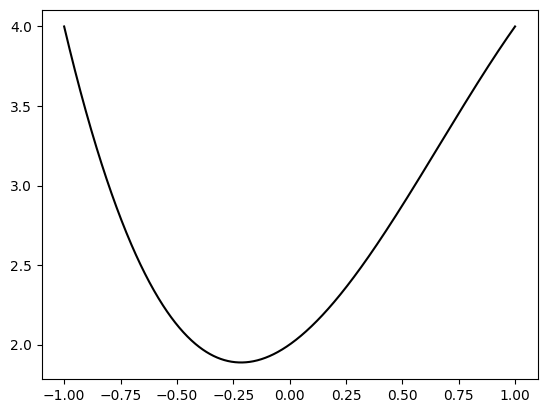

In [19]:
coefs = [2,1 ,2,-1]

def polynomial(coefs, x):
    n = len(coefs)
    return sum(coefs[i]*x**i for i in range(n))

def draw_polynomial(coefs):
    x = np.linspace(-1,1,1000)
    plt.plot(x,polynomial(coefs,x), linestyle='-',color ='black')

draw_polynomial(coefs)

Generating a dataset of 50 points 

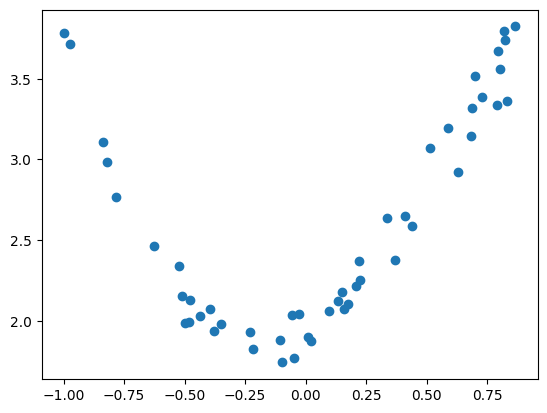

In [20]:
X = []
Y = []

for i in range(50):
    x = random.uniform(-1,1)
    y = polynomial(coefs,x) + random.gauss(0,0.1)
    X.append(x)
    Y.append(y)

plt.scatter(X,Y)

# Training a polynomial regression model

Plot a polynomial of degree 20 to our dataset. To observe how much it overfits

In [21]:
def train_model_regression(X, Y, degree, regularization = None, alpha = 1.0):
    X = np.array(X).reshape(-1,1)
    Y = np.array(Y)

    poly = PolynomialFeatures(degree=degree,include_bias=False)
    X_poly = poly.fit_transform(X)

    if regularization == 'L1':
        model = Lasso(alpha=alpha)
    elif regularization == 'L2':
        model = Lasso(alpha=alpha)
    else:
        model = LinearRegression()
    model.fit(X_poly,Y)

    return model

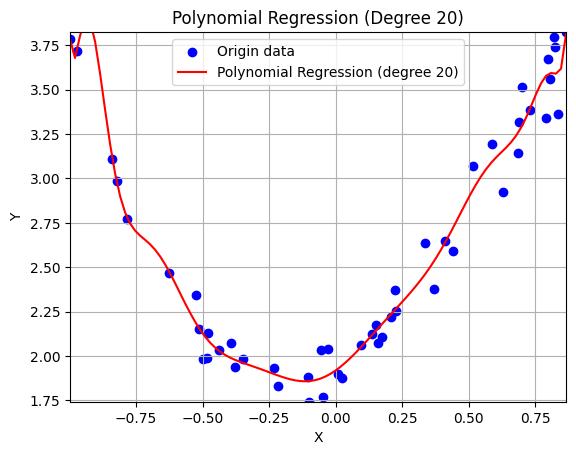

In [22]:
degree_used = 20
model = train_model_regression(X, Y, degree=degree_used)
plot_polynomial_regression(model, X, Y, degree_used)